# Large Dataset Benchmark — ChEMBL4649948 & ChEMBL4659961

Severely imbalanced binary classification on two large ChEMBL datasets.  
Two feature sets are compared per dataset:
- **Morgan**: 2 048-bit Morgan count fingerprints (integer, sparse)
- **Chemeleon**: 2 048-dim dense learned embeddings (float)

**Models:**
- `ZeroShotXGBClassifier` (portfolio=True) — zero-shot preset selection
- `XGBClassifier` defaults (n_estimators=100, scale_pos_weight corrected)
- `RandomForestClassifier` defaults (class_weight='balanced')

**Metrics:** AUROC, AUPR, train time  
**Protocol:** single stratified 80/20 train/test split

## 1. Load data

In [1]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

DATASETS = {
    "ChEMBL4659961": "../data/large/binary/chembl4659961_smiles_activity",
}

data = {}
for dname, base in DATASETS.items():
    morgan    = np.load(f"{base}/morgan_descriptor.npy").astype(np.float32)
    chemeleon = np.load(f"{base}/chemeleon_descriptor.npy").astype(np.float32)
    df        = pd.read_csv(f"{base}/data.csv")
    y         = df["activity"].values.astype(int)
    pos = y.sum(); neg = (y == 0).sum()
    print(f"{dname}: n={len(y):,}  pos={pos:,}  neg={neg:,}  imbalance={neg/pos:.0f}:1")
    print(f"  Morgan    shape: {morgan.shape}  dtype: {morgan.dtype}")
    print(f"  Chemeleon shape: {chemeleon.shape}  dtype: {chemeleon.dtype}")
    data[dname] = dict(morgan=morgan, chemeleon=chemeleon, y=y)

ChEMBL4659961: n=53,165  pos=898  neg=52,267  imbalance=58:1
  Morgan    shape: (53165, 2048)  dtype: float32
  Chemeleon shape: (53165, 2048)  dtype: float32


## 2. Dataset profiles

In [3]:
from sklearn.model_selection import train_test_split
from zsxgboost.inspector import inspect as profile_data

splits = {}  # "DatasetName — FeatureType" -> dict
for dname, d in data.items():
    y = d["y"]
    for fname, X in [("Morgan", d["morgan"])]:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
        key = f"{dname} — {fname}"
        splits[key] = dict(X_tr=X_tr, X_te=X_te, y_tr=y_tr, y_te=y_te, y=y)
        print(f"=== {key} ===")
        print(profile_data(X_tr, y_tr, task="classification"))
        print()

=== ChEMBL4659961 — Morgan ===
DatasetProfile(
  n_samples=42532, n_features=2048, n_p_ratio=20.77
  sparsity=0.970, is_sparse_counts=True
  binary_feature_fraction=0.382, feature_signal_strength=0.013
  task='classification'
  imbalance_ratio=58.24
  feature_signal_p90=0.024
)



## 3. Preset cost analysis (a priori)

In [ ]:
from zsxgboost.params import get_params
from zsxgboost.presets import xgb_default_params, flaml_params, autogluon_params, rf_params
from zsxgboost.model import _training_cost, _MAX_COST_MULTIPLIER

for key, sp in splits.items():
    X_tr, y_tr = sp["X_tr"], sp["y_tr"]
    prof = profile_data(X_tr, y_tr, task="classification")
    n_tr = len(y_tr)
    default_cost = _training_cost(xgb_default_params(prof, "cpu"), n_tr)
    budget = _MAX_COST_MULTIPLIER * default_cost
    print(f"=== {key} (n_tr={n_tr:,}, p={prof.n_features}, sparse_counts={prof.is_sparse_counts}) ===")
    print(f"  {'Preset':<12}  {'lr':>6}  {'patience':>8}  {'max_leaves':>10}  {'cost':>10}  {'ratio':>7}  status")
    print("  " + "-"*70)
    for pname, pfn in [("internal", None), ("default", xgb_default_params),
                       ("flaml", flaml_params), ("autogluon", autogluon_params),
                       ("rf_like", rf_params)]:
        p = pfn(prof, "cpu") if pfn else get_params(prof, "cpu")
        cost = _training_cost(p, n_tr)
        ratio = cost / default_cost
        ml = p.get("max_leaves", 2 ** p.get("max_depth", 6))
        skip = pname not in ("internal", "default") and cost > budget
        status = "SKIP (cost)" if skip else "run"
        print(f"  {pname:<12}  {p['learning_rate']:>6.4f}  "
              f"{p['early_stopping_rounds']:>8}  {ml:>10}  "
              f"{cost:>10.2e}  {ratio:>6.1f}x  {status}")
    print()

ValueError: task must be 'classification' or 'regression', got 'binary_classification'

## 4. Train and evaluate all models

In [ ]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from zsxgboost import ZeroShotXGBClassifier

results = {}

for key, sp in splits.items():
    X_tr, X_te = sp["X_tr"], sp["X_te"]
    y_tr, y_te = sp["y_tr"], sp["y_te"]
    imb = (sp["y"] == 0).sum() / sp["y"].sum()

    model_defs = {
        "zs-xgboost":  lambda: ZeroShotXGBClassifier(portfolio=True, verbose=True),
        "xgb-default": lambda imb=imb: xgb.XGBClassifier(
            n_estimators=100, tree_method="hist", nthread=-1, verbosity=0,
            scale_pos_weight=imb, eval_metric="aucpr"),
        "rf-default":  lambda: RandomForestClassifier(
            n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42),
    }

    results[key] = {}
    print(f"\n{'='*60}")
    print(f"  {key}")
    print(f"{'='*60}")
    for mname, clf_fn in model_defs.items():
        print(f"\n--- {mname} ---")
        clf = clf_fn()
        t0 = time.perf_counter()
        clf.fit(X_tr, y_tr)
        elapsed = time.perf_counter() - t0
        proba = clf.predict_proba(X_te)[:, 1]
        auroc = roc_auc_score(y_te, proba)
        aupr  = average_precision_score(y_te, proba)
        fpr, tpr, _ = roc_curve(y_te, proba)
        prec, rec, _ = precision_recall_curve(y_te, proba)
        preset = getattr(clf, "preset_name_", "-")
        results[key][mname] = dict(
            auroc=auroc, aupr=aupr, time=elapsed,
            preset=preset, fpr=fpr, tpr=tpr, prec=prec, rec=rec
        )
        print(f"  AUROC={auroc:.4f}  AUPR={aupr:.4f}  time={elapsed:.1f}s  preset={preset}")

        scores = getattr(clf, "portfolio_scores_", {})
        if scores:
            default_score = scores.get("default", float("nan"))
            print(f"\n  Portfolio scores (val AUC, higher = better):")
            for pname, sc in sorted(scores.items(), key=lambda x: -x[1]):
                marker = " ← selected" if pname == preset else ""
                gain   = f"  gain vs default: {sc - default_score:+.4f}" if pname != "default" else ""
                print(f"    {pname:<12}  {sc:.4f}{gain}{marker}")


  ChEMBL4659961 — Morgan

--- zs-xgboost ---


────────────────────────────────────────────── ZeroShotXGBClassifier ──────────────────────────────────────────────

Binary classification  n=42,532  |  p=2,048  |  n/p=20.8  |  imbalance=58.2:1  |  sparse_counts=True

11:20:53 INFO     device=cpu | portfolio=True


11:20:53 DEBUG    [portfolio] Stage 1 budget: rounds=108, patience=11 (n_tr=38278, scale=0.36)


...

────────────────────────────────────────────────────── Done ───────────────────────────────────────────────────────

11:21:31 SUCCESS  preset=internal | best_iteration=99


  AUROC=0.8100  AUPR=0.1715  time=38.6s  preset=internal

  Portfolio scores (val AUC, higher = better):
    internal      0.2149  gain vs default: +0.0880 ← selected
    default       0.1268
    flaml         0.0930  gain vs default: -0.0338
    rf_like       0.0730  gain vs default: -0.0538
    autogluon     0.0636  gain vs default: -0.0632

--- xgb-default ---


  AUROC=0.7336  AUPR=0.1104  time=1.9s  preset=-

--- rf-default ---


  AUROC=0.8002  AUPR=0.1642  time=3.1s  preset=-


## 5. Summary table

In [ ]:
rows = []
for key, res in results.items():
    dname, fname = key.split(" — ")
    for mname, r in res.items():
        rows.append({
            "Dataset":     dname,
            "Descriptors": fname,
            "Model":       mname,
            "AUROC":       round(r["auroc"], 4),
            "AUPR":        round(r["aupr"],  4),
            "Time (s)":    round(r["time"],  1),
            "Preset":      r["preset"],
        })

summary = pd.DataFrame(rows).set_index(["Dataset", "Descriptors", "Model"])
print(summary.to_string())

                                        AUROC    AUPR  Time (s)    Preset
Dataset       Descriptors Model                                          
ChEMBL4659961 Morgan      zs-xgboost   0.8100  0.1715      38.6  internal
                          xgb-default  0.7336  0.1104       1.9         -
                          rf-default   0.8002  0.1642       3.1         -


## 6. ROC and PR curves

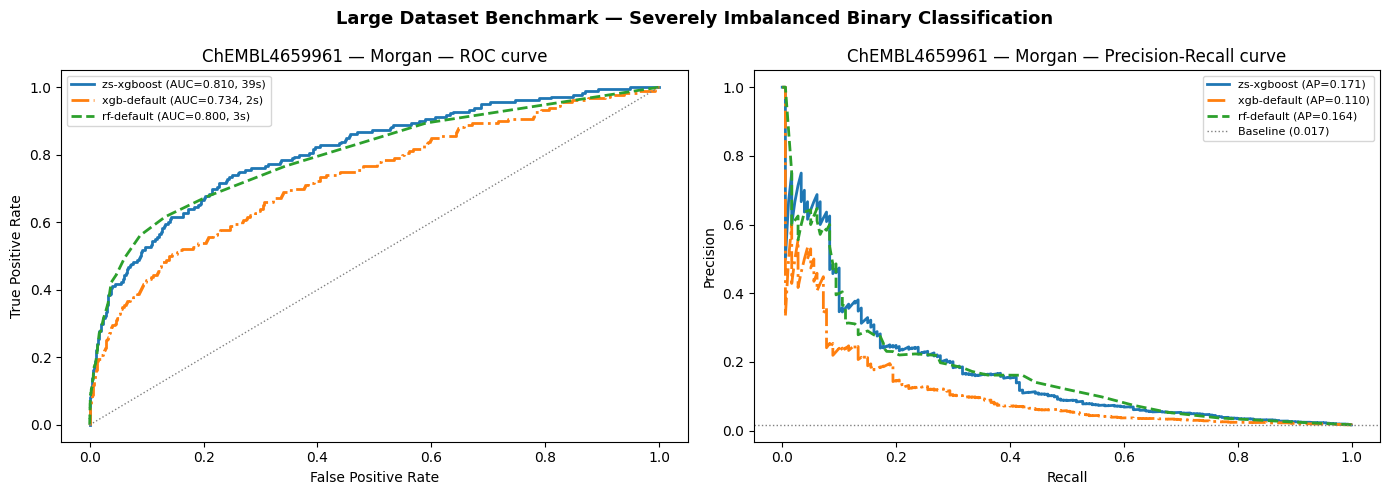

In [ ]:
import matplotlib.pyplot as plt

colors = {"zs-xgboost": "tab:blue", "xgb-default": "tab:orange", "rf-default": "tab:green"}
styles = {"zs-xgboost": "-",        "xgb-default": "-.",         "rf-default": "--"}

keys = list(results.keys())
fig, axes = plt.subplots(len(keys), 2, figsize=(14, 5 * len(keys)), squeeze=False)

for row_idx, key in enumerate(keys):
    ax_roc = axes[row_idx, 0]
    ax_pr  = axes[row_idx, 1]
    y_te   = splits[key]["y_te"]
    baseline_pr = y_te.mean()

    for mname, r in results[key].items():
        lbl_roc = f"{mname} (AUC={r['auroc']:.3f}, {r['time']:.0f}s)"
        lbl_pr  = f"{mname} (AP={r['aupr']:.3f})"
        ax_roc.plot(r["fpr"], r["tpr"], lw=2, color=colors[mname],
                    linestyle=styles[mname], label=lbl_roc)
        ax_pr.plot(r["rec"], r["prec"], lw=2, color=colors[mname],
                   linestyle=styles[mname], label=lbl_pr)

    ax_roc.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"{key} — ROC curve")
    ax_roc.legend(fontsize=8)

    ax_pr.axhline(baseline_pr, linestyle=":", color="grey", lw=1,
                  label=f"Baseline ({baseline_pr:.3f})")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"{key} — Precision-Recall curve")
    ax_pr.legend(fontsize=8)

plt.suptitle("Large Dataset Benchmark — Severely Imbalanced Binary Classification",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Training time comparison

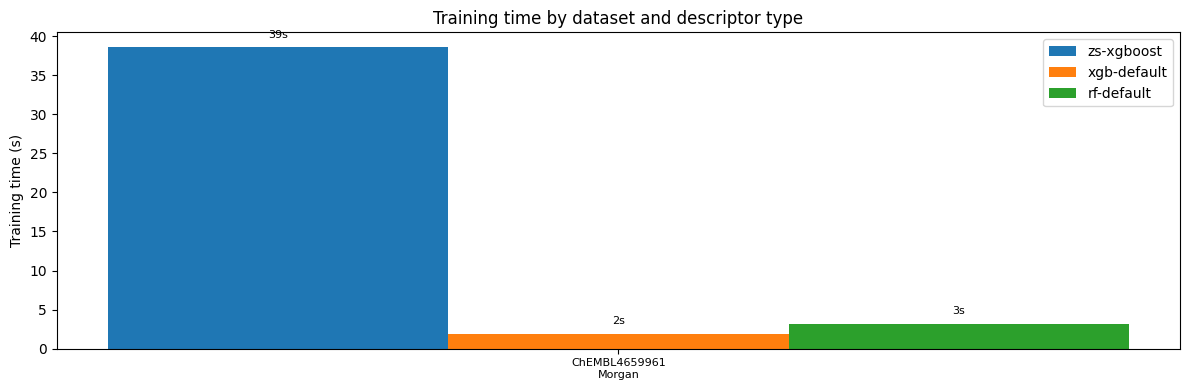

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

mnames = ["zs-xgboost", "xgb-default", "rf-default"]
x = np.arange(len(keys))
width = 0.25

for i, mname in enumerate(mnames):
    times = [results[k][mname]["time"] for k in keys]
    bars = ax.bar(x + i * width, times, width, label=mname,
                  color=list(colors.values())[i])
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{t:.0f}s", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([k.replace(" — ", "\n") for k in keys], fontsize=8)
ax.set_ylabel("Training time (s)")
ax.set_title("Training time by dataset and descriptor type")
ax.legend()
plt.tight_layout()
plt.show()